In [7]:
import os
import hopsworks
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# 1. Load your API key
load_dotenv()
api_key = os.getenv("HopsworkAPI_KEY")

project = hopsworks.login(api_key_value=api_key)

fs = project.get_feature_store()

fg = fs.get_feature_group("sialkot_aqi_features", version=1)
df = fg.read()

print(f"Total rows downloaded: {len(df)}")

2026-05-15 17:25:35,721 INFO: Closing external client and cleaning up certificates.
2026-05-15 17:25:35,727 INFO: Connection closed.
2026-05-15 17:25:35,729 INFO: Initializing external client
2026-05-15 17:25:35,729 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443




To ensure compatibility please install the latest bug fix release matching the minor version of your backend (4.7) by running 'pip install hopsworks==4.7.*'


2026-05-15 17:25:39,148 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32895
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (48.41s) 
Total rows downloaded: 1345


In [18]:
df.head(15)

,datetime,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,aqi,co,no2,o3,so2,pm2_5,pm10,nh3,date,hour,city
0,2026-02-27 15:00:00,7.8,0.0,18.6,9.0,0.32,84,5,1161.87,34.31,42.47,10.46,106.78,177.10,57.98,2026-02-27,15,Sialkot
1,2026-02-27 16:00:00,12.6,0.0,18.6,14.4,0.46,78,5,1500.10,43.08,27.34,11.47,135.00,214.88,69.39,2026-02-27,16,Sialkot
2,2026-02-27 17:00:00,13.9,0.0,18.3,14.4,0.54,74,5,1818.34,48.04,18.38,11.01,169.68,254.94,70.48,2026-02-27,17,Sialkot
3,2026-02-27 18:00:00,6.4,0.0,19.6,17.3,0.52,76,5,2001.47,48.39,18.21,9.81,203.91,286.28,64.46,2026-02-27,18,Sialkot
4,2026-02-27 19:00:00,8.9,0.0,17.8,16.2,0.31,84,5,1876.81,38.87,33.02,8.35,221.10,291.48,51.21,2026-02-27,19,Sialkot
5,2026-02-27 20:00:00,15.0,0.0,15.8,20.5,0.27,85,5,1842.00,33.48,30.12,5.73,237.10,299.69,43.48,2026-02-27,20,Sialkot
6,2026-02-27 21:00:00,9.9,0.0,15.6,17.6,0.22,87,5,1780.16,28.58,25.98,3.98,247.55,304.75,32.34,2026-02-27,21,Sialkot
7,2026-02-27 22:00:00,6.8,0.0,14.9,3.2,0.21,87,5,1697.75,24.23,21.56,2.91,252.52,306.36,24.33,2026-02-27,22,Sialkot
8,2026-02-27 23:00:00,13.1,0.0,13.8,13.7,0.27,84,5,1657.13,21.23,16.13,2.22,259.89,312.22,21.95,2026-02-27,23,Sialkot
9,2026-02-28 00:00:00,15.4,0.0,13.3,19.4,0.33,79,5,1644.77,19.27,10.81,1.90,269.59,322.07,22.63,2026-02-28,0,Sialkot


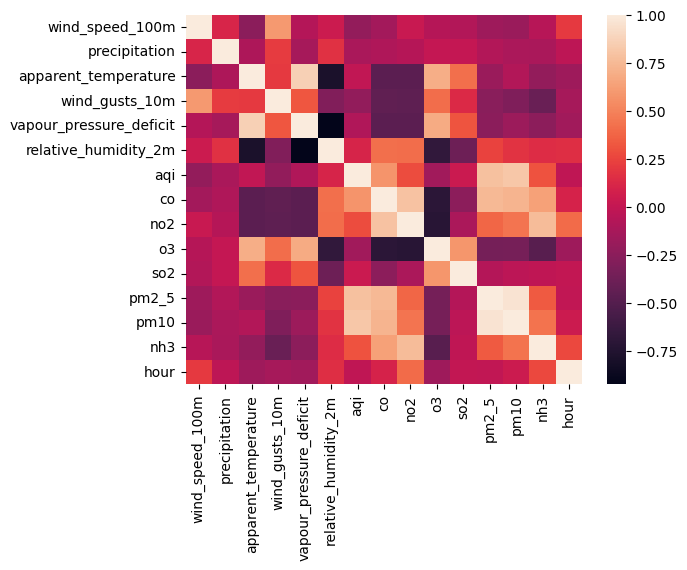

In [13]:
import seaborn as sns

data = df.corr(numeric_only=True)

# Create the heatmap
sns.heatmap(data)
plt.show()


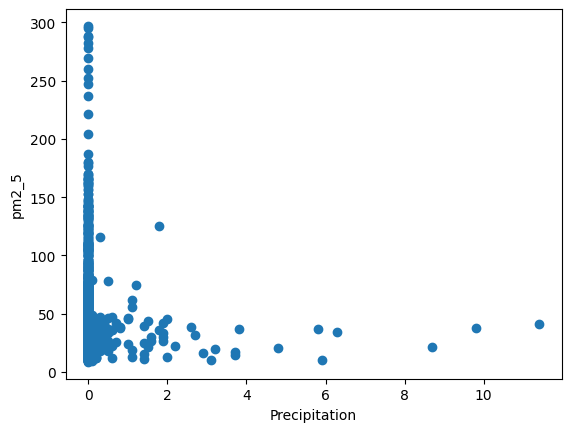

In [16]:
x = df['precipitation']
y = df['pm2_5']
plt.scatter(x,y)
plt.xlabel('Precipitation')
plt.ylabel('pm2_5')
plt.show()

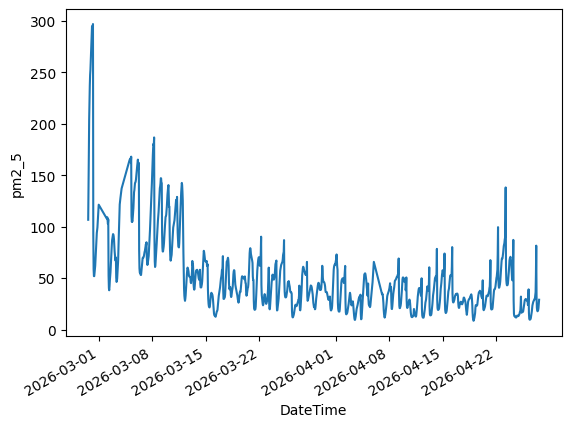

In [24]:
x = df['datetime']
y = df['pm2_5']
plt.plot(x,y)
plt.xlabel('DateTime')
plt.ylabel('pm2_5')
# This automatically rotates and formats the dates so they don't overlap!
plt.gcf().autofmt_xdate()
plt.show()